In [3]:
## Function 1

#Detect likely contamination sources in a two-dimensional area, 
#such as a radiation field, where only proximity yields a non-zero reading. 
#The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

#Challenge - readings are zero across most of your grid, creating a highly sparse, non-linear search space.
#The "Zero-Reading" Dead Zone: If your sensor is outside the radiation radius, the gradient is exactly zero. 
#Standard gradient-descent algorithms will fail because they cannot determine which direction to move


In [3]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm
from scipy.interpolate import griddata


7.710875114502849e-16
1.9508262577165927
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.650114   0.681526  ]
 [0.585859   0.565657  ]
 [0.616162   0.646465  ]
 [0.626263   0.646465  ]
 [0.626263   0.636364  ]
 [0.626263   0.626263  ]
 [0.626263   0.63636   ]
 [0.59596    0.626263  ]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -3.60621980e-003  2.13650746e-005
  6.20841713e-001  8.90421869e-001  1.70396218e+000  1.95082626e+000
  1.70422101e+000  9.55769944e-002]


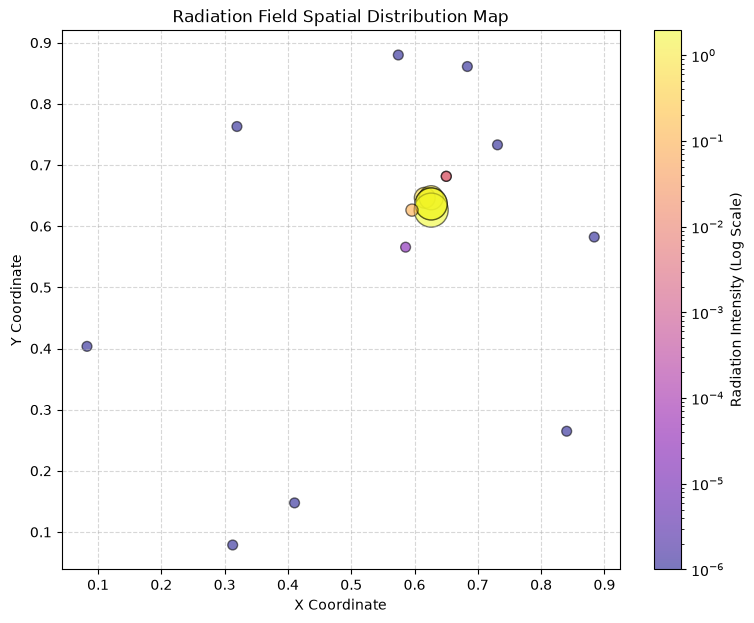

Strongest reading value after filtering: 1.9508262577165927
Likely source location coordinate:       [0.626263 0.626263]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Your 2D spatial coordinate data (10 positions)
coords = np.load('/home/mcevoyj777/_CAPSTONE/FUNC1/initial_inputs.npy')

# Your radiation intensity values
values = np.load('/home/mcevoyj777/_CAPSTONE/FUNC1/initial_outputs.npy')
print(values.max())
extra_inputs = [[0.650114, 0.681526],[0.585859,0.565657],[0.616162, 0.646465],
                [0.626263, 0.646465],[0.626263, 0.636364],[0.626263, 0.626263],
               [0.626263, 0.636360],[0.595960, 0.626263]]
extra_output = [-0.003606219797145482,0.00002136507463814,0.6208417126227237,0.8904218694712779,
                1.7039621839197536,1.9508262577165927,1.7042210119222299,0.09557699440564725]

coords = np.vstack([coords, extra_inputs])
values = np.append(values, extra_output)
print(values.max())
print (coords)
print (values)




x = coords[:, 0]
y = coords[:, 1]

# Handle negative values safely and establish a stable floor threshold
radiation_intensity = np.abs(values)
floor_threshold = 1e-6 # Set to a realistic detector noise floor (e.g., 1e-6)
radiation_intensity = np.where(radiation_intensity < floor_threshold, floor_threshold, radiation_intensity)

# Dynamically scale sizes between 50 and 600 so they stay positive and look great
raw_min, raw_max = radiation_intensity.min(), radiation_intensity.max()
if raw_max > raw_min:
    sizes = 50 + 550 * (radiation_intensity - raw_min) / (raw_max - raw_min)
else:
    sizes = 200 * np.ones_like(radiation_intensity) # Fallback if all values are identical

plt.figure(figsize=(9, 7))

# FIX: Pass the RAW intensities into colors.LogNorm instead of pre-logged values
scatter = plt.scatter(
    x, y, 
    c=radiation_intensity, 
    s=sizes, 
    cmap='plasma', 
    norm=colors.LogNorm(vmin=radiation_intensity.min(), vmax=radiation_intensity.max()),
    edgecolors='black',
    alpha=0.55
)

# Design elements
plt.colorbar(scatter, label="Radiation Intensity (Log Scale)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Radiation Field Spatial Distribution Map")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Find where your actual candidate source is hiding
strongest_idx = np.argmax(radiation_intensity)
print(f"Strongest reading value after filtering: {values[strongest_idx]}")
print(f"Likely source location coordinate:       {coords[strongest_idx]}")



📍 Current Position: [0.59596  0.626263]
🎯 Constrained Next Point (Within Radius 0.1): [0.65656566 0.62626263]


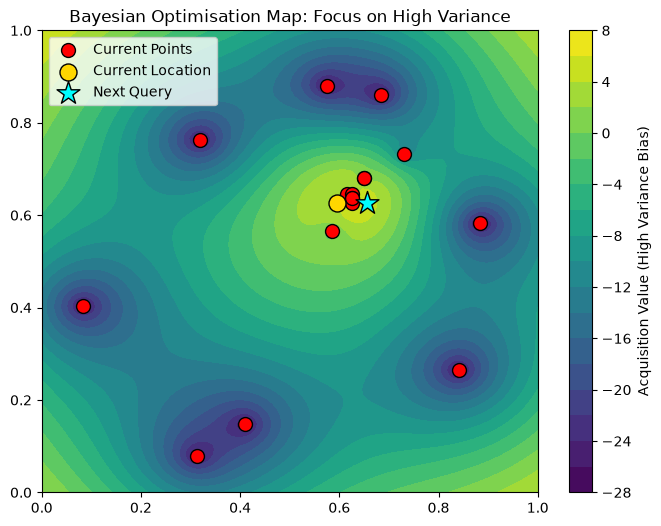

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors


# 2. Critical Step: Log-Transform the Target Space
# Takes absolute values and floors extremely tiny values to prevent log(-inf) issues.
y_clean = np.abs(values)
floor = 1e-30
y_clean = np.where(y_clean < floor, floor, y_clean)
y_log = np.log10(y_clean)

# 3. Fit the Gaussian Process Regressor
# A Matérn kernel allows the model to capture sharp, localized spikes.
kernel = Matern(length_scale=[1, 1], length_scale_bounds=(0.1, 1.0), nu=0.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5, n_restarts_optimizer=20)
gp.fit(coords, y_log)

# 4. Define a High-Variance (Exploratory) Acquisition Function
def high_variance_ucb(X_grid, gp_model, beta=20.0):
    """
    Acquisition Function: UCB = Mean + beta * Standard Deviation
    Setting beta high (e.g., 5.0 to 20.0) forces the search to focus on 
    high-variance unmapped zones rather than exploiting existing peaks.
    """
    mean, std = gp_model.predict(X_grid, return_std=True)
    return mean + (beta * std)

# Define your restricted physical movement radius (on a 0 to 1 normalized scale)
# For example: 0.1 means you can move at most 10% of the map's width per step
PROXIMITY_RADIUS = 0.05  

# Identify where your sampler is physically located right now (the last row of coords)
current_position = coords[-1] 

# Generate the search grid as before
x_span = np.linspace(0.0, 1.0, 100)
y_span = np.linspace(0.0, 1.0, 100)
X_mesh, Y_mesh = np.meshgrid(x_span, y_span)
grid_points = np.c_[X_mesh.ravel(), Y_mesh.ravel()]

# --- PHYSICAL CONSTRAINT FILTER ---
# Calculate the straight-line distance from current_position to every point on the grid
distances = np.linalg.norm(grid_points - current_position, axis=1)

# Create a boolean mask: True for points within the allowed radius
valid_radius_mask = distances <= PROXIMITY_RADIUS

# Evaluate the acquisition values across the entire map
acq_values = high_variance_ucb(grid_points, gp, beta=20.0)

# Set the acquisition value of ALL points OUTSIDE your radius to a massive negative number
# This guarantees np.argmax will never pick them, without ruining the data for your plot
acq_values_constrained = np.copy(acq_values)
acq_values_constrained[~valid_radius_mask] = -1e10

# Reshape the unconstrained values for the plotting mesh
acq_grid = acq_values.reshape(X_mesh.shape)

# Find the absolute best coordinate point *strictly within your radius*
best_idx = np.argmax(acq_values_constrained)
next_query_point = grid_points[best_idx]

print(f"📍 Current Position: {current_position}")
print(f"🎯 Constrained Next Point (Within Radius {PROXIMITY_RADIUS}): {next_query_point}")

# 6. Optional: Visualize the acquisition field map
plt.figure(figsize=(8, 6))
plt.contourf(X_mesh, Y_mesh, acq_grid, cmap='viridis', levels=20)
plt.colorbar(label='Acquisition Value (High Variance Bias)')
plt.scatter(coords[:, 0], coords[:, 1], color='red', edgecolor='black', s=100, label='Current Points')
plt.scatter(current_position[0], current_position[1], color='gold', edgecolor='black', s=150, marker='o', label='Current Location')
plt.scatter(next_query_point[0], next_query_point[1], color='cyan', marker='*', s=300, edgecolor='black', label='Next Query')
plt.legend()
plt.title("Bayesian Optimisation Map: Focus on High Variance")
plt.show()

